In [12]:
# --- All Imports ---
import mysql.connector
import pandas as pd
import requests
import time
import ipaddress
import logging
import os 
from datetime import datetime, timedelta
import matplotlib.pyplot as plt 
import seaborn as sns
from datetime import timedelta
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb



In [ ]:


# --- Database connection details ---
# IMPORTANT: Replace with your actual database credentials if different
DB_CONFIG = {
    'host': 'localhost',
    'user': 'root',
    'password': '* CHANGE TO YOUR PASSWORD*',
    'database': '* CHANGE TO YOUR DATABASE NAME*',
    'port': 3306
}

# --- Initialize DataFrames ---
df_activity = pd.DataFrame()
df_weather = pd.DataFrame()
df_activity_with_weather = pd.DataFrame()

# --- CELL 1: Database Connection, df_activity Loading, and Initial Data Preparation ---
print("--- CELL 1: Database Connection, df_activity Loading, and Initial Data Preparation ---")

try:
    # Establish the connection
    cnx = mysql.connector.connect(**DB_CONFIG)
    if cnx.is_connected():
        print("Successfully connected to the database.")
    else:
        print("Failed to connect to the database.")
        raise ConnectionError("Database connection failed.")

    # Fetching the combined user activity table
    print("\nFetching data from 'combined_user_activity' table...")
    query_activity = "SELECT * FROM combined_user_activity;"
    df_activity = pd.read_sql(query_activity, cnx)

    print(f"'combined_user_activity' table loaded. Rows: {len(df_activity)}")
    print("Head of df_activity (initial load):")
    print(df_activity.head())
    print("\nInitial Info of df_activity:")
    df_activity.info()

    # Initial Data Cleaning and Type Conversion for df_activity
    print("\n--- Performing Data Type Conversions for df_activity ---")

    # Convert 'activity_created_on' to datetime objects
    df_activity['activity_created_on'] = pd.to_datetime(df_activity['activity_created_on'])
    print("Converted 'activity_created_on' to datetime.")

    # Convert 'currenttime' and 'lasteditedon' (if they are datetime-like and not already)
    for col in ['currenttime', 'lasteditedon']:
        if col in df_activity.columns and df_activity[col].dtype == 'object':
            df_activity[col] = pd.to_datetime(df_activity[col], errors='coerce')
            if df_activity[col].isnull().any():
                print(f"Warning: Some values in '{col}' could not be converted to datetime and were set to NaT.")
            print(f"Converted '{col}' to datetime.")
    
    # Convert numeric columns like 'duration' and 'amount' if they are not already numeric
    for col in ['duration', 'amount']:
        if col in df_activity.columns and not pd.api.types.is_numeric_dtype(df_activity[col]):
            df_activity[col] = pd.to_numeric(df_activity[col], errors='coerce')
            if df_activity[col].isnull().any():
                print(f"Warning: Some values in '{col}' could not be converted to numeric and were set to NaN.")
            print(f"Converted '{col}' to numeric.")

    # Ensure 'country_code' is properly set for merging (based on previous discussions, assuming 'locale' if 'country_code' is missing)
    if 'country_code' not in df_activity.columns:
        print("Warning: 'country_code' column not found directly. Assuming 'locale' can serve as country code for now.")
        df_activity['country_code'] = df_activity['locale']
    print(f"Using column '{'country_code' if 'country_code' in df_activity.columns else 'locale'}' for country identification.")

    print("\nUpdated Info of df_activity after conversions:")
    df_activity.info()
    print("\nFirst 5 rows of df_activity after conversions:")
    print(df_activity.head())

except mysql.connector.Error as err:
    print(f"MySQL Error: {err}")
    if err.errno == mysql.connector.errorcode.ER_ACCESS_DENIED_ERROR:
        print("Something is wrong with your user name or password")
    elif err.errno == mysql.connector.errorcode.ER_BAD_DB_ERROR:
        print("Database does not exist")
    else:
        print(err)
except Exception as e:
    print(f"An unexpected error occurred during data loading or conversion: {e}")
finally:
    if 'cnx' in locals() and cnx.is_connected():
        cnx.close()
        print("\nDatabase connection closed.")

print("\n--- df_activity loading and initial processing complete. ---")

if df_activity.empty:
    print("\nCRITICAL ERROR: df_activity is empty. Please resolve database connection/query issues before proceeding.")
else:
    print(f"\nSuccessfully loaded {len(df_activity)} records into df_activity.")

--- CELL 1: Database Connection, df_activity Loading, and Initial Data Preparation ---
Successfully connected to the database.

Fetching data from 'combined_user_activity' table...


/tmp/ipykernel_371115/2809171812.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_activity = pd.read_sql(query_activity, cnx)


'combined_user_activity' table loaded. Rows: 38988
Head of df_activity (initial load):
  record_type  activity_id  user_id  content_id    platform  \
0        view           40        1          30  Windows 10   
1        view           38        1          31  Windows 10   
2        view           18        1           7  Windows 10   
3        view           17        1          25     Android   
4        view           12        1           1  Windows 10   

  activity_created_on  currenttime        ipaddress        lasteditedon  \
0 2019-09-30 14:32:41         31.0      154.70.0.67 2020-03-15 16:32:18   
1 2019-09-30 13:29:16        794.0      154.70.0.67 2020-03-15 16:32:18   
2 2019-09-19 16:56:55        728.0      41.90.65.92 2020-03-18 20:29:14   
3 2019-09-17 00:51:53       2613.0      154.70.0.67 2020-03-15 16:32:18   
4 2019-08-23 15:29:37       4685.0  197.237.247.155 2020-03-15 16:32:18   

                   title                                             genres  \
0   

In [14]:
# --- CELL 2: Load Weather Data from CSV ---
print("\n--- CELL 2: Load Weather Data from CSV ---")

try:
    # --- Using the full path you provided in previous interactions ---
    # IMPORTANT: Update this path if your weather_data.CSV is in a different location
    csv_file_path = r'/home/user/Downloads/yakwetu/combined_daily_weather_Jan_2019_to_July_2025.csv'
    df_weather = pd.read_csv(csv_file_path)

    print(f"\nWeather data loaded from CSV: {csv_file_path}. Rows: {len(df_weather)}")
    print("Head of df_weather (initial load):")
    print(df_weather.head())
    print("\nInitial Info of df_weather:")
    df_weather.info()

    # Data Type Conversions for df_weather
    # Convert the date column in your weather CSV ('time' based on your screenshot) to datetime objects
    if 'time' in df_weather.columns:
        df_weather['time'] = pd.to_datetime(df_weather['time'], errors='coerce').dt.date
        print("Converted 'time' column in df_weather to date objects.")
    elif 'date' in df_weather.columns:
        df_weather['date'] = pd.to_datetime(df_weather['date'], errors='coerce').dt.date
        print("Converted 'date' column in df_weather to date objects.")
    elif 'weather_date' in df_weather.columns:
        df_weather['weather_date'] = pd.to_datetime(df_weather['weather_date'], errors='coerce').dt.date
        print("Converted 'weather_date' column in df_weather to date objects.")
    else:
        print("Warning: No common date column ('time', 'date', or 'weather_date') found in your weather CSV for conversion. Please adjust the code if needed.")
        
    print("\nUpdated Info of df_weather after initial conversions:")
    df_weather.info()
    
except FileNotFoundError:
    print(f"ERROR: Weather data CSV not found at '{csv_file_path}'. Please check the file path and name.")
    print("Make sure the file exists and the path is correct, including case-sensitivity for the filename.")
except Exception as e:
    print(f"An error occurred while loading or processing the weather CSV: {e}")

if df_weather.empty:
    print("\nCRITICAL ERROR: df_weather is empty. Please ensure your CSV is correctly loaded and has data.")
else:
    print(f"\nSuccessfully loaded {len(df_weather)} records into df_weather from CSV.")


--- CELL 2: Load Weather Data from CSV ---

Weather data loaded from CSV: /home/user/Downloads/yakwetu/combined_daily_weather_Jan_2019_to_July_2025.csv. Rows: 9608
Head of df_weather (initial load):
         time  temperature_2m_max  temperature_2m_min  \
0  2019-01-01                24.8                13.9   
1  2019-01-02                25.4                14.3   
2  2019-01-03                24.6                15.0   
3  2019-01-04                20.8                15.3   
4  2019-01-05                22.7                13.9   

   apparent_temperature_max  apparent_temperature_min  precipitation_sum  \
0                      25.5                      13.0                0.0   
1                      26.0                      13.7                0.0   
2                      25.0                      14.8                0.1   
3                      21.7                      15.6               13.5   
4                      22.7                      13.9                5.6   



In [15]:
# --- CELL 3: Prepare df_weather for Merge ---
print("\n--- CELL 3: Prepare df_weather for Merge ---")


if not df_weather.empty:
    # Rename the 'time' column to 'weather_date' for consistency and clearer merge
    if 'time' in df_weather.columns:
        df_weather.rename(columns={'time': 'weather_date'}, inplace=True)
        print("Renamed 'time' column in df_weather to 'weather_date'.")
    elif 'date' in df_weather.columns and 'weather_date' not in df_weather.columns:
        df_weather.rename(columns={'date': 'weather_date'}, inplace=True)
        print("Renamed 'date' column in df_weather to 'weather_date'.")
    
    # Ensure 'weather_date' is in date format (important for merging)
    if 'weather_date' in df_weather.columns:
         df_weather['weather_date'] = pd.to_datetime(df_weather['weather_date'], errors='coerce').dt.date
         print("Ensured 'weather_date' column is in date format.")
    else:
        print("Warning: 'weather_date' column (or original 'time'/'date') not found after renaming. Check Cell 2 and this cell's renaming logic.")
       
    # Add a 'country_code' column to df_weather based on the 'city' column
    # IMPORTANT: Ensure these mappings are correct for your specific data.
    if 'city' in df_weather.columns:
        df_weather['country_code'] = df_weather['city'].map({
            'Nairobi': 'KE',
            'Lagos': 'NG',
            'Dubai': 'AE',
            'New York': 'US',
            # Add more city: country_code mappings as needed
        })
        print("Added 'country_code' to df_weather based on 'city' column.")
        if df_weather['country_code'].isnull().any():
            print("Warning: Some cities in df_weather could not be mapped to a country_code. Check 'city' column for unmapped values.")
            print("Cities with no country_code assigned:", df_weather[df_weather['country_code'].isnull()]['city'].unique())
    else:
        print("Warning: 'city' column not found in df_weather. Cannot infer 'country_code'. Please add 'country_code' manually or from another source if your CSV doesn't contain it.")

    # Aggregate df_weather by country_code and weather_date
    # This is crucial because df_activity will no longer have a 'city' column for merging,
    # and we need a single, representative weather entry per country per day.
    print("\nAggregating df_weather by country_code and weather_date...")
    
    # Define aggregation methods for numerical and categorical columns
    aggregation_methods = {
        col: 'mean' for col in df_weather.select_dtypes(include=['number']).columns if col not in ['weathercode']
    }
    # For weathercode, use mode (most frequent)
    if 'weathercode' in df_weather.columns:
        aggregation_methods['weathercode'] = lambda x: x.mode()[0] if not x.mode().empty else None

    # Ensure 'weather_date' and 'country_code' are not included in aggregation values
    if 'weather_date' in aggregation_methods:
        del aggregation_methods['weather_date']
    if 'country_code' in aggregation_methods:
        del aggregation_methods['country_code']
    if 'city' in aggregation_methods: # Remove city from aggregation values, it's a grouping key
        del aggregation_methods['city']

    df_weather_aggregated = df_weather.groupby(['country_code', 'weather_date']).agg(aggregation_methods).reset_index()
    
    print("Aggregation complete. Head of aggregated weather data:")
    print(df_weather_aggregated.head())
    print("\nInfo of df_weather_aggregated:")
    df_weather_aggregated.info()

    # Replace the original df_weather with the aggregated one for the merge
    df_weather = df_weather_aggregated

    print("\nUpdated Head of df_weather after preparation:")
    print(df_weather.head())
    print("\nUpdated Info of df_weather after preparation:")
    df_weather.info()
else:
    print("df_weather is empty, skipping preparation for merge.")


--- CELL 3: Prepare df_weather for Merge ---
Renamed 'time' column in df_weather to 'weather_date'.
Ensured 'weather_date' column is in date format.
Added 'country_code' to df_weather based on 'city' column.

Aggregating df_weather by country_code and weather_date...


Aggregation complete. Head of aggregated weather data:
  country_code weather_date  temperature_2m_max  temperature_2m_min  \
0           AE   2019-01-01                25.4                15.2   
1           AE   2019-01-02                25.9                15.5   
2           AE   2019-01-03                28.0                14.3   
3           AE   2019-01-04                26.0                17.0   
4           AE   2019-01-05                24.8                16.4   

   apparent_temperature_max  apparent_temperature_min  precipitation_sum  \
0                      26.0                      15.2                0.0   
1                      25.9                      15.0                0.0   
2                      26.9                      12.8                0.0   
3                      25.6                      15.4                0.0   
4                      25.3                      16.0                0.0   

   rain_sum  windspeed_10m_max  weathercode  
0       0.0    

In [16]:
# --- CELL 4: IP Address Geolocation and City Extraction for df_activity ---
# This cell has been removed as per your request.
# The 'city' column will no longer be added to df_activity via IP geolocation.

In [17]:
# --- CELL 5: Perform the Merge of df_activity and df_weather ---
print("\n--- CELL 5: Perform the Merge with Weather Data ---")

# Ensure 'activity_date' is available in df_activity (from Cell 1 or created here for safety)
if 'activity_date' not in df_activity.columns:
    df_activity['activity_date'] = df_activity['activity_created_on'].dt.date

# Determine the date column name in df_weather for merging
weather_date_col = None
if 'date' in df_weather.columns:
    weather_date_col = 'date'
elif 'weather_date' in df_weather.columns:
    weather_date_col = 'weather_date'
elif 'time' in df_weather.columns: # Fallback if not renamed yet
    weather_date_col = 'time'
    
if weather_date_col is None:
    print("ERROR: No suitable date column found in df_weather for merging. Please check Cell 2 and Cell 3.")
else:
    df_activity_with_weather = pd.merge(
        df_activity,
        df_weather,
        # Merging only on country_code and date, as city is no longer in df_activity
        left_on=['country_code', 'activity_date'],
        right_on=['country_code', 'weather_date'],
        how='left' # Use left join to keep all activity records
    )

    # Drop the redundant weather date column after merge if it's different from activity_date
    if weather_date_col != 'activity_date' and weather_date_col in df_activity_with_weather.columns:
        df_activity_with_weather = df_activity_with_weather.drop(columns=[weather_date_col])

    print("\nShape of df_activity_with_weather after merging with weather:", df_activity_with_weather.shape)
    print("Head of df_activity_with_weather (showing new weather columns):")
    print(df_activity_with_weather.head())
    print("\nInfo of df_activity_with_weather:")
    df_activity_with_weather.info()

    print("\n--- Weather Data Integration Complete! ---")
    print("Your 'df_activity_with_weather' DataFrame now contains combined user activity and historical weather information.")


--- CELL 5: Perform the Merge with Weather Data ---



Shape of df_activity_with_weather after merging with weather: (38988, 29)
Head of df_activity_with_weather (showing new weather columns):
  record_type  activity_id  user_id  content_id    platform  \
0        view           40        1          30  Windows 10   
1        view           38        1          31  Windows 10   
2        view           18        1           7  Windows 10   
3        view           17        1          25     Android   
4        view           12        1           1  Windows 10   

  activity_created_on  currenttime        ipaddress        lasteditedon  \
0 2019-09-30 14:32:41         31.0      154.70.0.67 2020-03-15 16:32:18   
1 2019-09-30 13:29:16        794.0      154.70.0.67 2020-03-15 16:32:18   
2 2019-09-19 16:56:55        728.0      41.90.65.92 2020-03-18 20:29:14   
3 2019-09-17 00:51:53       2613.0      154.70.0.67 2020-03-15 16:32:18   
4 2019-08-23 15:29:37       4685.0  197.237.247.155 2020-03-15 16:32:18   

                   title  ... c

In [18]:
# --- CELL 6: Handle NaN values from UNION ALL and Weather Merge ---
print("\n--- CELL 6: Handle NaN values from UNION ALL and Weather Merge ---")

# --- Handling NaN from UNION ALL (e.g., 'platform' for purchases, 'amount' for views) ---
print("\nHandling NaNs from UNION ALL operation (e.g., 'platform' for purchases, 'amount' for views)...")

# Categorical columns where NaN means 'Not Applicable'
union_categorical_cols = ['platform', 'ipaddress', 'source', 'currency', 'purchase_type']
for col in union_categorical_cols:
    if col in df_activity_with_weather.columns and df_activity_with_weather[col].dtype == 'object':
        # Use direct assignment instead of inplace=True to avoid FutureWarning
        df_activity_with_weather[col] = df_activity_with_weather[col].fillna('N/A')
        print(f"Filled NaN in '{col}' with 'N/A'.")

# Numerical columns where NaN means 'Not Applicable' (keep as NaN or fill with 0 based on context)
# For 'currenttime' (view duration) and 'amount' (purchase amount), NaN is meaningful.
# If a model absolutely requires no NaNs, you might fill with 0, but be cautious.
# For this general setup, we'll leave them as NaN, as many ML models can handle them.
# If you need to fill them, uncomment the lines below:
# if 'currenttime' in df_activity_with_weather.columns:
#     df_activity_with_weather['currenttime'] = df_activity_with_weather['currenttime'].fillna(0)
#     print("Filled NaN in 'currenttime' with 0.")
# if 'amount' in df_activity_with_weather.columns:
#     df_activity_with_weather['amount'] = df_activity_with_weather['amount'].fillna(0)
#     print("Filled NaN in 'amount' with 0.")

# 'lasteditedon' is datetime, NaT is appropriate for missing.

# --- Handling NaNs from Weather Data Merge ---
print("\nHandling NaNs from weather data merge (truly missing weather info)...")

# Get list of weather columns (adjust if your weather CSV has different names)
weather_cols = [
    'temperature_2m_max', 'temperature_2m_min', 'apparent_temperature_max',
    'apparent_temperature_min', 'precipitation_sum', 'rain_sum',
    'weathercode', 'windspeed_10m_max'
]

# Impute numerical weather columns
for col in weather_cols:
    if col in df_activity_with_weather.columns:
        if df_activity_with_weather[col].isnull().any():
            # For precipitation, 0 is a reasonable fill if data is missing
            if 'precipitation' in col or 'rain' in col:
                # Use direct assignment instead of inplace=True
                df_activity_with_weather[col] = df_activity_with_weather[col].fillna(0)
                print(f"Imputed missing '{col}' with 0.")
            # For temperature and windspeed, median is a robust choice
            elif 'temperature' in col or 'windspeed' in col:
                median_val = df_activity_with_weather[col].median()
                # Use direct assignment instead of inplace=True
                df_activity_with_weather[col] = df_activity_with_weather[col].fillna(median_val)
                print(f"Imputed missing '{col}' with median: {median_val:.2f}.")
            # For weathercode, mode or a specific placeholder like -1
            elif 'weathercode' in col:
                # Option 1: Fill with mode
                mode_val = df_activity_with_weather[col].mode()[0]
                # Use direct assignment instead of inplace=True
                df_activity_with_weather[col] = df_activity_with_weather[col].fillna(mode_val)
                print(f"Imputed missing '{col}' with mode: {mode_val}.")
                # Option 2: Fill with a distinct numerical placeholder (e.g., -1)
                # df_activity_with_weather[col] = df_activity_with_weather[col].fillna(-1)
                # print(f"Imputed missing '{col}' with -1.")

# --- Final Verification of NaNs ---
print("\nFinal NaN counts in df_activity_with_weather after all handling:")
print(df_activity_with_weather.isnull().sum())

print("\nHead of df_activity_with_weather after all NaN handling:")
print(df_activity_with_weather.head())

print("\n--- Data Preparation Complete! ---")
print("Your 'df_activity_with_weather' DataFrame is now ready for Exploratory Data Analysis and Feature Engineering.")


--- CELL 6: Handle NaN values from UNION ALL and Weather Merge ---

Handling NaNs from UNION ALL operation (e.g., 'platform' for purchases, 'amount' for views)...
Filled NaN in 'platform' with 'N/A'.
Filled NaN in 'ipaddress' with 'N/A'.
Filled NaN in 'source' with 'N/A'.


Filled NaN in 'currency' with 'N/A'.
Filled NaN in 'purchase_type' with 'N/A'.

Handling NaNs from weather data merge (truly missing weather info)...
Imputed missing 'temperature_2m_max' with median: 25.00.
Imputed missing 'temperature_2m_min' with median: 15.20.
Imputed missing 'apparent_temperature_max' with median: 25.90.
Imputed missing 'apparent_temperature_min' with median: 15.30.
Imputed missing 'precipitation_sum' with 0.
Imputed missing 'rain_sum' with 0.
Imputed missing 'weathercode' with mode: 51.0.
Imputed missing 'windspeed_10m_max' with median: 13.60.

Final NaN counts in df_activity_with_weather after all handling:
record_type                     0
activity_id                     0
user_id                         0
content_id                      0
platform                        0
activity_created_on             0
currenttime                 29426
ipaddress                       0
lasteditedon                29426
title                           0
genres                

In [19]:
df_activity_with_weather['amount']

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
38983    0.0
38984    0.0
38985    0.0
38986    0.0
38987    0.0
Name: amount, Length: 38988, dtype: float64

In [20]:
# --- CELL 7: Exploratory Data Analysis (EDA) - Descriptive Statistics ---
print("\n--- CELL 7: Exploratory Data Analysis (EDA) - Descriptive Statistics ---")

if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform EDA. Please ensure previous cells ran successfully.")
else:
    print("\n--- Descriptive Statistics for Numerical Columns ---")
    print(df_activity_with_weather.describe().to_string()) # Use .to_string() to ensure full display


--- CELL 7: Exploratory Data Analysis (EDA) - Descriptive Statistics ---

--- Descriptive Statistics for Numerical Columns ---
        activity_id       user_id    content_id            activity_created_on   currenttime                   lasteditedon      duration          year        amount  temperature_2m_max  temperature_2m_min  apparent_temperature_max  apparent_temperature_min  precipitation_sum      rain_sum  windspeed_10m_max   weathercode
count  38988.000000  38988.000000  38988.000000                          38988   9562.000000                           9562  38988.000000  38988.000000  34207.000000        38988.000000        38988.000000              38988.000000              38988.000000       38988.000000  38988.000000       38988.000000  38988.000000
mean   11814.196753  12276.857392    117.043962  2023-11-17 14:59:32.631066112   2656.757791  2023-03-03 19:49:28.780380672     68.951960   2020.373371    146.696009           25.162388           14.934939                 25

In [21]:
df_activity_with_weather.head(3)

,record_type,activity_id,user_id,content_id,platform,activity_created_on,currenttime,ipaddress,lasteditedon,title,...,country_code,activity_date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,windspeed_10m_max,weathercode
0,view,40,1,30,Windows 10,2019-09-30 14:32:41,31.0,154.70.0.67,2020-03-15 16:32:18,SUPA MODO,...,KE,2019-09-30,28.8,15.0,28.5,14.4,1.2,1.2,13.0,51.0
1,view,38,1,31,Windows 10,2019-09-30 13:29:16,794.0,154.70.0.67,2020-03-15 16:32:18,LUSALA,...,KE,2019-09-30,28.8,15.0,28.5,14.4,1.2,1.2,13.0,51.0
2,view,18,1,7,Windows 10,2019-09-19 16:56:55,728.0,41.90.65.92,2020-03-18 20:29:14,THE BODA BODA THIEVES,...,KE,2019-09-19,26.2,11.3,26.3,10.6,0.0,0.0,18.8,3.0


In [22]:
# --- CELL 8: Exploratory Data Analysis (EDA) - Record Type Distribution ---
print("\n--- CELL 8: Exploratory Data Analysis (EDA) - Record Type Distribution ---")

if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform EDA. Please ensure previous cells ran successfully.")
else:
    print("\n--- Record Type Distribution ---")
    print(df_activity_with_weather['record_type'].value_counts().to_string())


--- CELL 8: Exploratory Data Analysis (EDA) - Record Type Distribution ---

--- Record Type Distribution ---
record_type
purchase    29426
view         9562


In [23]:
# --- CELL 9: Exploratory Data Analysis (EDA) - Country Code Distribution ---
print("\n--- CELL 9: Exploratory Data Analysis (EDA) - Country Code Distribution ---")

if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform EDA. Please ensure previous cells ran successfully.")
else:
    print("\n--- Country Code Distribution ---")
    print(df_activity_with_weather['country_code'].value_counts().to_string())


--- CELL 9: Exploratory Data Analysis (EDA) - Country Code Distribution ---

--- Country Code Distribution ---
country_code
KE    35960
NG      655
US      587
NZ      214
UG      191
RW      183
TZ      173
GB      143
AE       92
CA       83
IN       68
QA       58
AU       58
DE       58
FR       49
ZA       46
SA       34
NL       29
CH       27
BE       19
GH       18
SE       14
IT       11
ET       11
LB       10
SI       10
TH       10
HR        9
MU        8
KY        8
NO        8
RO        7
SS        7
TR        7
KW        6
SC        6
UA        6
IE        6
SO        6
JP        6
SG        4
PL        4
MW        4
BH        4
ZW        4
BW        4
GR        3
CD        3
CG        3
HK        3
ID        2
JE        2
RS        2
DZ        2
EG        2
ES        2
GA        2
BR        2
MX        2
AT        2
FI        2
IL        2
ZM        2
IQ        2
BI        2
HU        2
DJ        2
GY        1
CW        1
CI        1
PK        1
DK        1
EE        1

In [24]:
# --- CELL 10: Exploratory Data Analysis (EDA) - Platform Distribution ---
print("\n--- CELL 10: Exploratory Data Analysis (EDA) - Platform Distribution ---")

if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform EDA. Please ensure previous cells ran successfully.")
else:
    print("\n--- Platform Distribution (after NaN handling) ---")
    print(df_activity_with_weather['platform'].value_counts().to_string())


--- CELL 10: Exploratory Data Analysis (EDA) - Platform Distribution ---

--- Platform Distribution (after NaN handling) ---
platform
N/A                 29426
Android              5684
Windows 10           2838
Mac OS X              592
Linux                 198
Windows 7             134
Windows 8.1            58
iOS                    42
Unknown Platform       10
Windows 8               6


In [25]:
# --- CELL 11: Exploratory Data Analysis (EDA) - Purchase Type Distribution ---
print("\n--- CELL 11: Exploratory Data Analysis (EDA) - Purchase Type Distribution ---")

if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform EDA. Please ensure previous cells ran successfully.")
else:
    print("\n--- Purchase Type Distribution (after NaN handling) ---")
    print(df_activity_with_weather['purchase_type'].value_counts().to_string())


--- CELL 11: Exploratory Data Analysis (EDA) - Purchase Type Distribution ---

--- Purchase Type Distribution (after NaN handling) ---
purchase_type
RENTAL                       18870
PVOD                          6217
N/A                           4781
                              4781
EST                           2452
SCREENING                      576
ZOOM SCREENING                 556
REGULAR OFFLINE SCREENING      248
OFFLINE SCREENING              159
BULK OFFLINE SCREENING         117
DUO OFFLINE SCREENING           79
TRIO OFFLINE SCREENING          34
MONO OFFLINE SCREENING          29
COUPLE OFFLINE SCREENING        29
OFFLINE SCREENIN                23
GETUP KENYA 2024                10
DOOR OFFLINE SCREENING           7
SCREENING (DUO)                  5
STUDENT OFFLINE SCREENING        5
SQUAD OFFLINE SCREENING          4
KDHC 2024                        3
GROUP OFFLINE SCREENING          2
UPSELL TO EST                    1


### Distribution of Max temp 

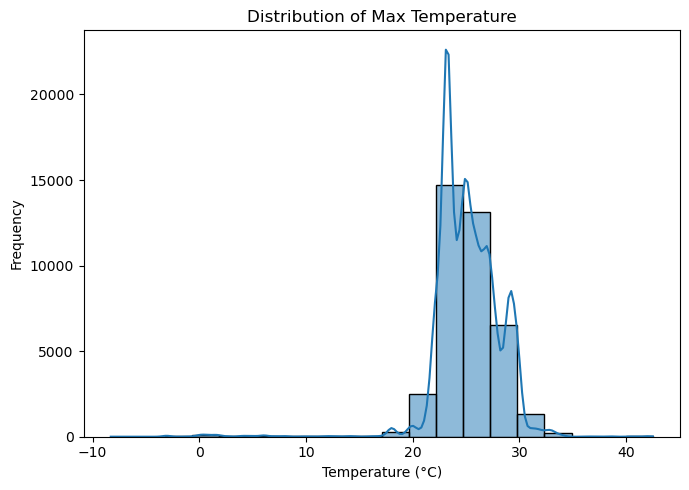

In [26]:
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    plt.figure(figsize=(7, 5)) # Adjusted size for single plot
    sns.histplot(df_activity_with_weather['temperature_2m_max'], kde=True, bins=20)
    plt.title('Distribution of Max Temperature')
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

* The histogram above shows the distribution of maximum temperatures across all regions in df_activity_with_weather.

* Most days had max temperatures between 22°C and 30°C — those are the tallest bars. 

* Very few days were colder than 15°C or hotter than 35°C — those bars are tiny

### The histogram for 'precipitation_sum'

It will show the distribution of precipitation values across the dataset, helping to identify patterns or anomalies in weather data. 

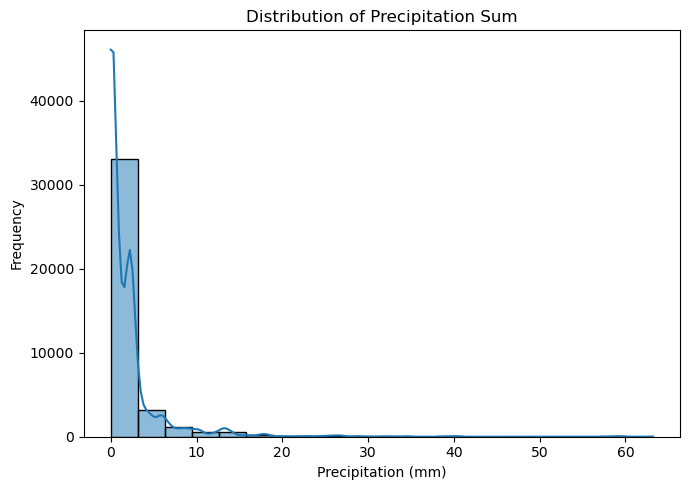

In [27]:
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    plt.figure(figsize=(7, 5)) # Adjusted size for single plot
    sns.histplot(df_activity_with_weather['precipitation_sum'], kde=True, bins=20)
    plt.title('Distribution of Precipitation Sum')
    plt.xlabel('Precipitation (mm)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

* The tallest bars are between 0 and 10 mm, with the peak around 0-5 mm, reaching approximately 30,000 to 35,000 occurrences. This indicates that the vast majority of days had very little rain—less than 10 mm. This could suggest a generally dry climate or many days with trace amounts of precipitation.

* The frequency drops significantly beyond 10 mm. The bar for 10-20 mm is much shorter (around 5,000-10,000 occurrences), and it continues to decrease sharply as precipitation increases.This shows that moderate to heavy rain (above 10 mm) is much rarer, with only a few thousand occurrences at most.

* Precipitation amounts between 20 mm and 60 mm have very low frequencies, likely a few hundred or fewer occurrences. This suggests that heavy rainfall is uncommon.The tail extends to 60 mm, but the frequency is near zero, indicating that extreme precipitation is exceptionally rare.

### Distribution of Record Types

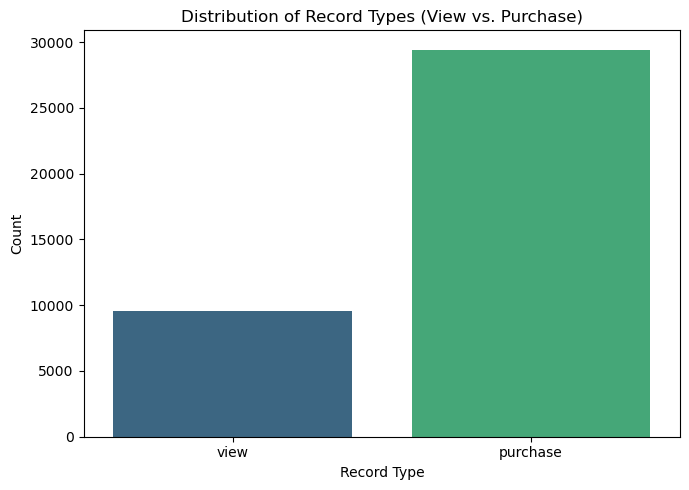

In [28]:
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    plt.figure(figsize=(7, 5)) 
    sns.countplot(x='record_type', data=df_activity_with_weather, palette='viridis', hue='record_type', legend=False)
    plt.title('Distribution of Record Types (View vs. Purchase)')
    plt.xlabel('Record Type')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

* The purchase bar is significantly taller, reaching approximately 28,000 to 30,000 counts. This indicates that there are a very high number of purchase records in the dataset—almost 30,000 instances.

* The view bar is shorter, reaching around 10,000 to 12,000 counts. This shows that there are far fewer view records, about one-third the number of purchase records.

* This distribution could guide business decisions, such as focusing marketing on encouraging purchases rather than just views, or investigating why views are less frequent.

### Distribution of windspeed

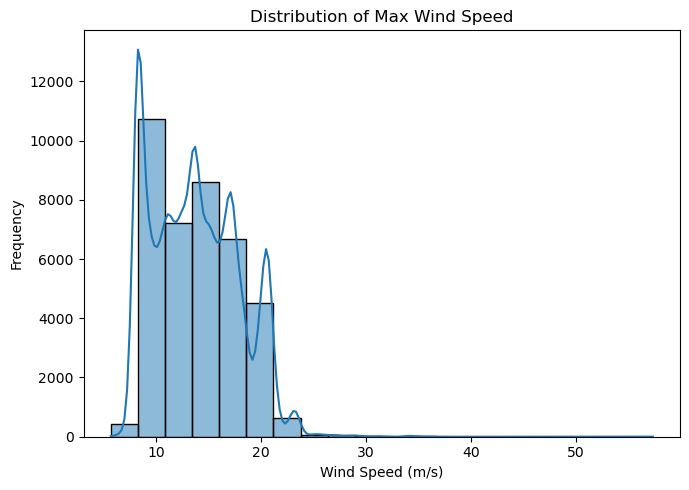

In [29]:
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    plt.figure(figsize=(7, 5)) 
    sns.histplot(df_activity_with_weather['windspeed_10m_max'], kde=True, bins=20)
    plt.title('Distribution of Max Wind Speed')
    plt.xlabel('Wind Speed (m/s)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

* The tallest bars are between 0 and 20 m/s, with the highest peak around 5-10 m/s, reaching approximately 10,000 to 12,000 occurrences. This indicates that the majority of recorded wind speeds are relatively low to moderate—less than 20 m/s. This could reflect typical weather conditions in the cities.

* There are noticeable peaks around 5-10 m/s, 15-20 m/s, and a smaller one near 25-30 m/s. This suggests multiple common wind speed ranges, possibly due to different weather patterns (e.g., calm days, breezy days, and occasional gusts).The dip between 10-15 m/s and the rise again at 15-20 m/s indicate a bimodal or multimodal distribution, where wind speeds cluster around certain values rather than following a smooth decline.

* Beyond 20 m/s, the frequency drops sharply. The bar for 20-30 m/s is much shorter (around 2,000-4,000 occurrences), and it continues to decrease to near zero by 40-50 m/s. This shows that high wind speeds (above 20 m/s) are much rarer, with only a few hundred or fewer occurrences. Wind speeds above 30 m/s are extremely uncommon in this dataset.

* In conclusion the cities experience predominantly calm to moderate wind conditions, with occasional stronger gusts. Wind speeds above 20 m/s (e.g., strong breezes or storms) are infrequent, which might align with a temperate or coastal climate with occasional weather disturbances.

### Distribution of weather conditions

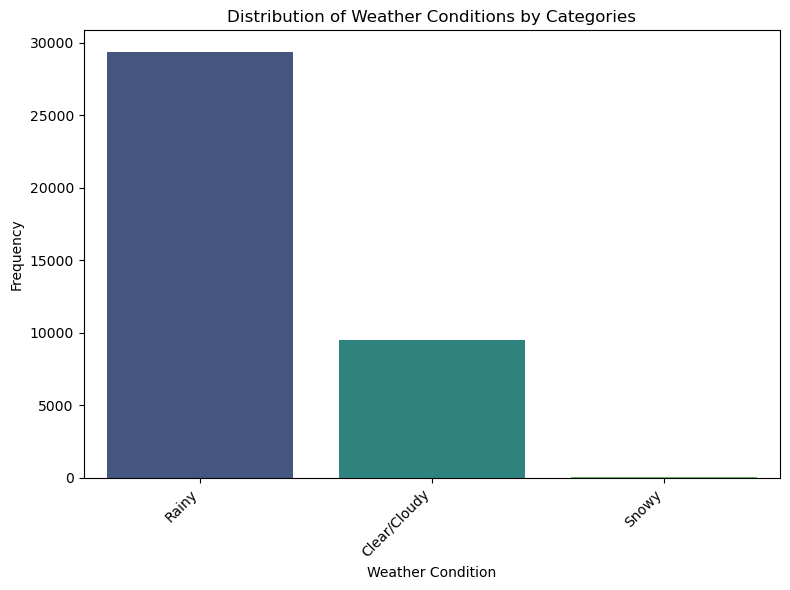

In [30]:
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    # Define map_weathercode_to_condition function locally for this cell's execution
    def map_weathercode_to_condition(code):
        if code in [0, 1, 2, 3]: # Clear sky, partly cloudy
            return 'Clear/Cloudy'
        elif code in [45, 48]: # Fog, depositing rime fog
            return 'Foggy'
        elif code in [51, 53, 55, 56, 57, 61, 63, 65, 66, 67, 80, 81, 82]: # Drizzle, Rain, Rain showers
            return 'Rainy'
        elif code in [71, 73, 75, 77, 85, 86]: # Snow, snow grains, snow showers
            return 'Snowy'
        # Removed Freezing Rain/Drizzle as per user request
        elif code in [95, 96, 99]: # Thunderstorm, thunderstorm with hail
            return 'Thunderstorm'
        else:
            return 'Other' # Catch any unmapped codes
    
    # Create 'weather_condition_category' column if not already present
    if 'weather_condition_category' not in df_activity_with_weather.columns:
        df_activity_with_weather['weather_condition_category'] = df_activity_with_weather['weathercode'].apply(map_weathercode_to_condition)

    plt.figure(figsize=(8, 6)) 
    sns.countplot(x='weather_condition_category', data=df_activity_with_weather, palette='viridis', hue='weather_condition_category', legend=False)
    plt.title('Distribution of Weather Conditions by Categories')
    plt.xlabel('Weather Condition')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

* The plot clearly shows that 'Rainy' conditions are the most frequent, followed by 'Clear/Cloudy'. 'Snowy' conditions are very rare in
 the cities.

### Distribution of users across Country Codes 

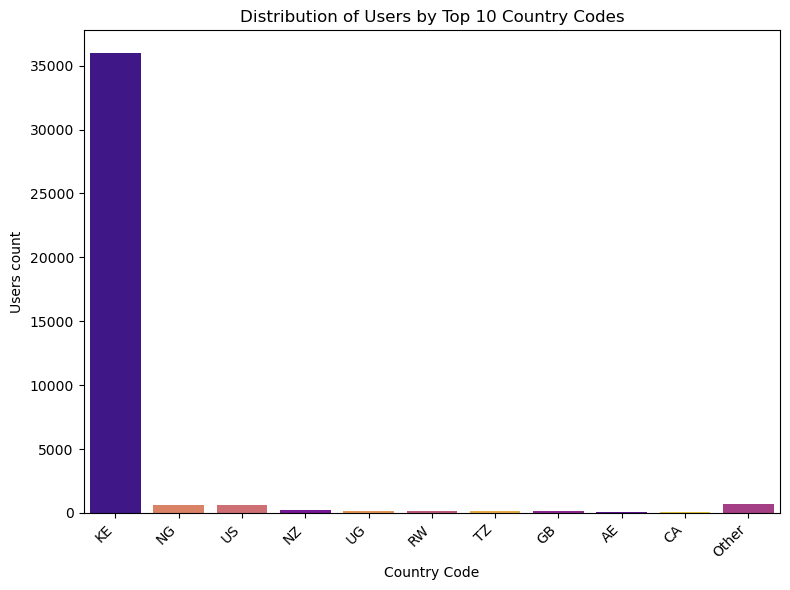

In [31]:
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    # Calculate value counts for country codes
    country_counts = df_activity_with_weather['country_code'].value_counts()
    
    # Define N for top countries (e.g., top 10)
    N = 10 
    top_countries = country_counts.head(N).index
    
    # Create a new DataFrame for plotting, including 'Other' category
    df_plot_countries = df_activity_with_weather.copy()
    df_plot_countries['country_code_grouped'] = df_plot_countries['country_code'].apply(lambda x: x if x in top_countries else 'Other')

    plt.figure(figsize=(8, 6)) # Adjusted size for better readability
    # Use order to ensure 'Other' is at the end if desired, or let seaborn sort by count
    sns.countplot(x='country_code_grouped', data=df_plot_countries, palette='plasma', 
                  order=top_countries.tolist() + ['Other'] if 'Other' in df_plot_countries['country_code_grouped'].unique() else top_countries.tolist(),
                  hue='country_code_grouped', legend=False) # Added hue and legend=False
    plt.title(f'Distribution of Users by Top {N} Country Codes')
    plt.xlabel('Country Code')
    plt.ylabel('Users count')
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
    plt.tight_layout()
    plt.show()

*  The plot visually emphasizes the overwhelming dominance of the number of users in 'KE' (Kenya) in the dataset, with other top countries (NG, US, NZ, UG, TZ, RW, GB, AE, CA) having much smaller, but still visible, counts. The 'Other' category aggregates the long tail of less frequent countries.

### Correlation of weather conditions to record types

In [32]:
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform deeper EDA. Please ensure previous cells ran successfully.")
else:
    print("The following cells (CELL 20 onwards) contain deeper visualizations exploring relationships between weather, activity, and content.")
    # Define map_weathercode_to_condition function globally for deeper EDA plots
    def map_weathercode_to_condition(code):
        if code in [0, 1, 2, 3]: # Clear sky, partly cloudy
            return 'Clear/Cloudy'
        elif code in [45, 48]: # Fog, depositing rime fog
            return 'Foggy'
        elif code in [51, 53, 55, 56, 57, 61, 63, 65, 66, 67, 80, 81, 82]: # Drizzle, Rain, Rain showers
            return 'Rainy'
        elif code in [71, 73, 75, 77, 85, 86]: # Snow, snow grains, snow showers
            return 'Snowy'
        elif code in [95, 96, 99]: # Thunderstorm, thunderstorm with hail
            return 'Thunderstorm'
        else:
            return 'Other' # Catch any unmapped codes
    
    # Create 'weather_condition_category' column if not already present, for use in subsequent cells
    if 'weather_condition_category' not in df_activity_with_weather.columns:
        df_activity_with_weather['weather_condition_category'] = df_activity_with_weather['weathercode'].apply(map_weathercode_to_condition)

The following cells (CELL 20 onwards) contain deeper visualizations exploring relationships between weather, activity, and content.


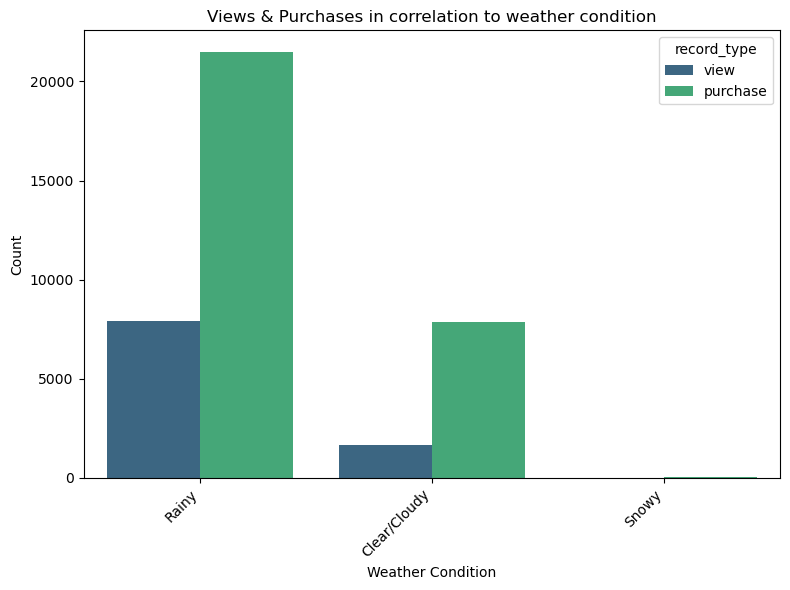

In [33]:
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    # Ensure weather_condition_category is available (created in CELL 19)
    # If df_activity_with_weather was reloaded without CELL 19, this would need to be re-run
    # For robustness, include the definition here too if it's not guaranteed to be run before
    # For now, assuming CELL 19 (Overview) is run first.
    
    plt.figure(figsize=(8, 6)) # Adjusted size for single plot
    sns.countplot(x='weather_condition_category', hue='record_type', data=df_activity_with_weather, palette='viridis')
    plt.title('Views & Purchases in correlation to weather condition')
    plt.xlabel('Weather Condition')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

* This plot is crucial. It shows that both 'view' and 'purchase' activities are most frequent during 'Rainy' conditions, followed by 'Clear/Cloudy'. 'Snowy' conditions have negligible activity. This suggests that adverse weather (like rain) might lead to more indoor activity, potentially increasing content consumption and purchases.

### Record Type Distribution by Temperature Range

Created 'temp_range' column.


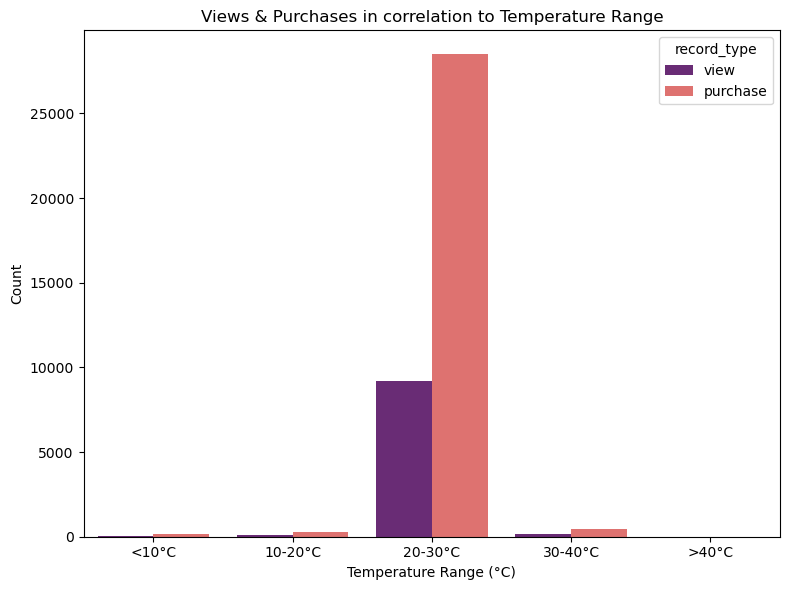

In [34]:
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    # Create temperature bins if not already present
    if 'temp_range' not in df_activity_with_weather.columns:
        df_activity_with_weather['temp_range'] = pd.cut(df_activity_with_weather['temperature_2m_max'],
                                                        bins=[-10, 10, 20, 30, 40, 50],
                                                        labels=['<10°C', '10-20°C', '20-30°C', '30-40°C', '>40°C'],
                                                        right=False)
        print("Created 'temp_range' column.")

    plt.figure(figsize=(8, 6)) # Adjusted size for single plot
    sns.countplot(x='temp_range', hue='record_type', data=df_activity_with_weather, palette='magma', order=['<10°C', '10-20°C', '20-30°C', '30-40°C', '>40°C'])
    plt.title('Views & Purchases in correlation to Temperature Range')
    plt.xlabel('Temperature Range (°C)')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

* The plot indicates that the '20-30°C' temperature range is where the vast majority of both 'view' and 'purchase' activities occur. This is a significant finding, suggesting an optimal temperature range for user engagement on the platform. Activity in other temperature ranges is minimal.

### Average View Duration by Weather Condition

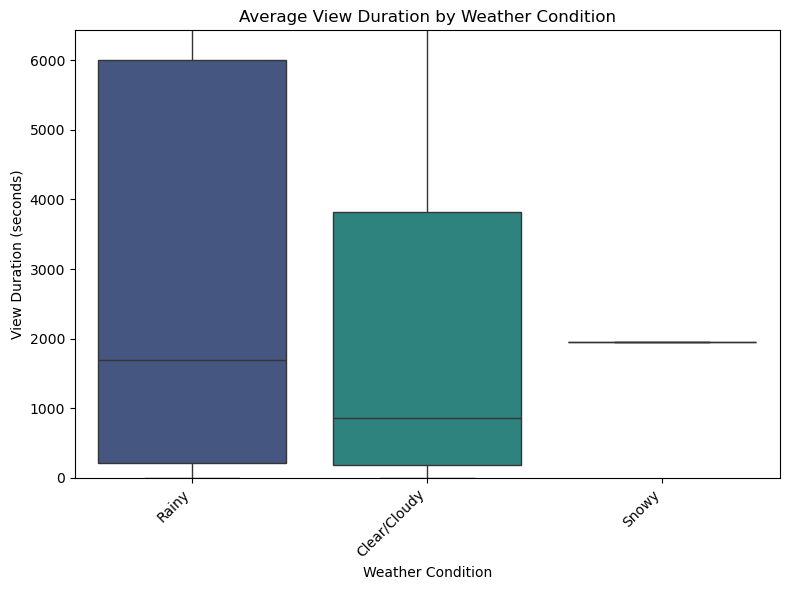

In [35]:
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    df_views = df_activity_with_weather[df_activity_with_weather['record_type'] == 'view'].copy()
    
    plt.figure(figsize=(8, 6)) # Adjusted size for single plot
    sns.boxplot(x='weather_condition_category', y='currenttime', data=df_views, hue='weather_condition_category', palette='viridis', legend=False)
    plt.title('Average View Duration by Weather Condition')
    plt.xlabel('Weather Condition')
    plt.ylabel('View Duration (seconds)')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, df_views['currenttime'].quantile(0.95)) # Limit y-axis to focus on main distribution
    plt.tight_layout()
    plt.show()


* The box plot suggests that average view duration might be higher during 'Rainy' conditions compared to 'Clear/Cloudy' or 'Snowy' (though 'Snowy' has very few data points). The box for 'Rainy' appears to have a higher median and potentially a wider spread, indicating longer viewing sessions.

### Average Purchase Amount by Weather Condition

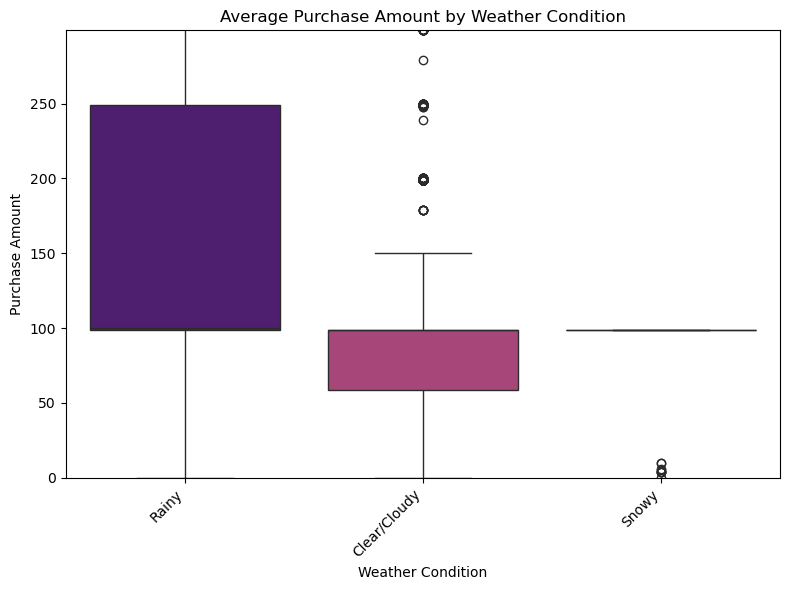

In [36]:
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    df_purchases = df_activity_with_weather[df_activity_with_weather['record_type'] == 'purchase'].copy()
    
    plt.figure(figsize=(8, 6)) # Adjusted size for single plot
    sns.boxplot(x='weather_condition_category', y='amount', data=df_purchases, hue='weather_condition_category', palette='magma', legend=False)
    plt.title('Average Purchase Amount by Weather Condition')
    plt.xlabel('Weather Condition')
    plt.ylabel('Purchase Amount')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, df_purchases['amount'].quantile(0.95)) # Limit y-axis to focus on main distribution
    plt.tight_layout()
    plt.show()

* Similar to view duration, the plot indicates that average purchase amounts might be higher during 'Rainy' conditions. The box for 'Rainy' shows a higher median purchase amount and a larger interquartile range compared to 'Clear/Cloudy' and 'Snowy', suggesting more substantial purchases during rainy periods.

### Correlation Heatmap

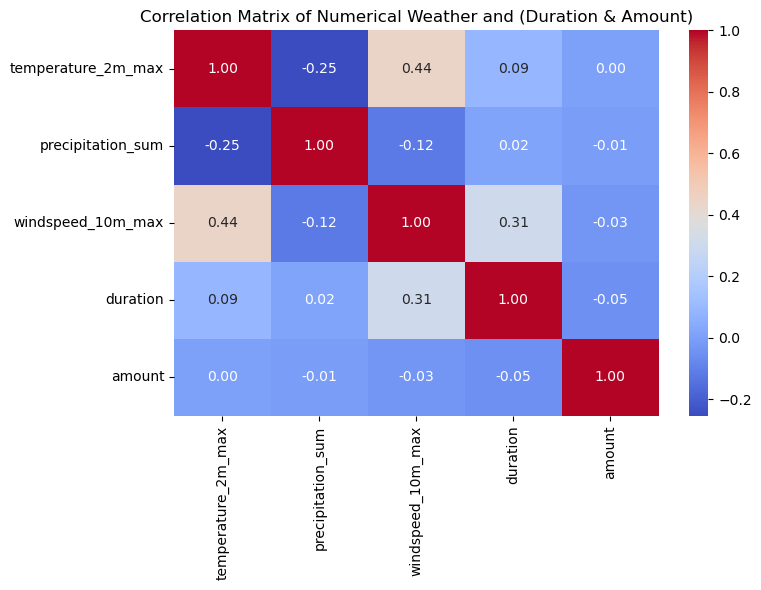

In [37]:
if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform visualization. Please ensure previous cells ran successfully.")
else:
    numerical_cols = ['temperature_2m_max', 'precipitation_sum', 'windspeed_10m_max', 'duration', 'amount']
    corr_df = df_activity_with_weather[numerical_cols].dropna()
    
    plt.figure(figsize=(8, 6)) # Adjusted size for single plot
    sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Numerical Weather and (Duration & Amount)')
    plt.tight_layout()
    plt.show()


* Weak correlations are observed between weather metrics and activity metrics. For example, precipitation_sum has a very low positive correlation with duration (0.02) and amount (-0.01). Similarly, temperature_2m_max and windspeed_10m_max also show very weak correlations with duration and amount. This suggests that while weather categories (as seen in previous plots) might show some patterns, the numerical values of individual weather parameters don't have a strong linear relationship with activity duration or amount.

###  Genre Analysis Setup & Top Genres by Weather Condition


--- Genre Analysis by Weather ---


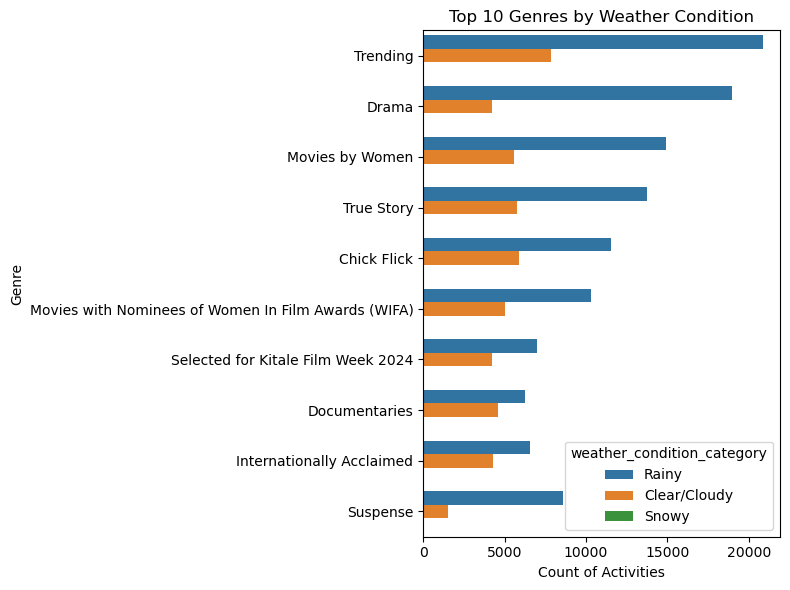

In [38]:

import warnings
warnings.filterwarnings("ignore")

if df_activity_with_weather.empty:
    print("df_activity_with_weather is empty. Cannot perform genre analysis. Please ensure previous cells ran successfully.")
else:
    print("\n--- Genre Analysis by Weather ---")

    # Explode genres into separate rows for analysis
    # First, clean up genres column if it still has non-list strings (e.g., 'N/A')
    # Convert string representation of list to actual list
    df_activity_with_weather['genres_list'] = df_activity_with_weather['genres'].apply(
        lambda x: eval(x) if isinstance(x, str) and x.startswith('[') and x.endswith(']') else []
    )
    # Filter out empty lists or 'N/A' from genres_list
    df_genres_exploded = df_activity_with_weather.explode('genres_list').reset_index(drop=True)
    df_genres_exploded = df_genres_exploded[df_genres_exploded['genres_list'].apply(lambda x: x not in ['N/A', '', 'TEST', 'TESTED'])]
    
    if not df_genres_exploded.empty:
        # Top Genres by Weather Condition (Count of activities)
        plt.figure(figsize=(8, 6))
        sns.countplot(y='genres_list', hue='weather_condition_category', data=df_genres_exploded, order=df_genres_exploded['genres_list'].value_counts().index[:10], palette='tab10')
        plt.title('Top 10 Genres by Weather Condition')
        plt.xlabel('Count of Activities')
        plt.ylabel('Genre')
        plt.tight_layout()
        plt.show()
    else:
        print("No valid genre data found after exploding for genre analysis.")


* The plot shows the most popular genres overall and how their popularity shifts across different weather conditions. For example, 'Trending' and 'Drama' appear to be consistently popular across 'Rainy' and 'Clear/Cloudy' conditions. This can inform content scheduling and promotion based on anticipated weather.

### Average View Duration for Top 5 Genres by Weather Condition

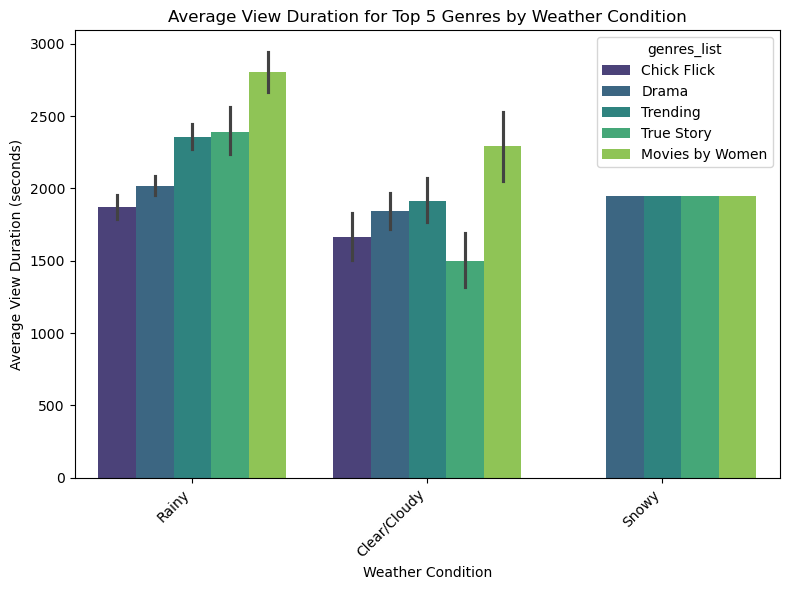

In [39]:

plt.figure(figsize=(8, 6))
sns.barplot(x='weather_condition_category', y='currenttime', hue='genres_list',
                data=df_genres_exploded[df_genres_exploded['genres_list'].isin(df_genres_exploded['genres_list'].value_counts().index[:5])], # Top 5 genres
                estimator=lambda x: pd.Series(x).dropna().mean(), palette='viridis')
plt.title('Average View Duration for Top 5 Genres by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average View Duration (seconds)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



* This plot provides a more granular view of how specific genres perform under different weather conditions in terms of engagement. For instance, 'Drama' seems to have a slightly higher average view duration during 'Rainy' conditions compared to 'Clear/Cloudy'. This insight can be valuable for tailoring content recommendations or pricing strategies for specific genres based on weather forecasts.

In [40]:
# check the columns of the final DataFrame
df_activity_with_weather.columns

Index(['record_type', 'activity_id', 'user_id', 'content_id', 'platform',
       'activity_created_on', 'currenttime', 'ipaddress', 'lasteditedon',
       'title', 'genres', 'duration', 'content_country', 'year', 'locale',
       'purchase_type', 'amount', 'source', 'currency', 'country_code',
       'activity_date', 'temperature_2m_max', 'temperature_2m_min',
       'apparent_temperature_max', 'apparent_temperature_min',
       'precipitation_sum', 'rain_sum', 'windspeed_10m_max', 'weathercode',
       'weather_condition_category', 'temp_range', 'genres_list'],
      dtype='object')

## FEATURE ENGINEERING

We are going to use simulation to determine Watch Window: Using start_time and last_edit_time to define the potential days of watching.
And simulates daily watch times for a single viewing activity, distributing the total_watch_time across days between start_time and last_edit_time.

In [41]:
def simulate_watch_sessions(start_time, last_edit_time, total_watch_time, weekend_weight=2.0):

    if pd.isna(start_time) or pd.isna(last_edit_time) or pd.isna(total_watch_time) or total_watch_time <= 0:
        return {}

    start_date = start_time.date()
    last_edit_date = last_edit_time.date()

    num_days = (last_edit_date - start_date).days + 1
    
    if num_days == 1:
        return {str(start_date): total_watch_time}

    watch_days = [start_date + timedelta(days=i) for i in range(num_days)]

    daily_weights = []
    for day in watch_days:
        if day.weekday() in [5, 6]:  # Saturday or Sunday
            daily_weights.append(weekend_weight)
        else:
            daily_weights.append(1.0)
    
    if total_watch_time < num_days:
        return {str(start_date): total_watch_time}

    total_weight = sum(daily_weights)
    simulated_daily_times = {}
    
    for i, day in enumerate(watch_days):
        if total_weight > 0:
            proportion = daily_weights[i] / total_weight
            assigned_time = total_watch_time * proportion
            simulated_daily_times[str(day)] = assigned_time
            
    if simulated_daily_times:
        current_sum = sum(simulated_daily_times.values())
        if current_sum > 0:
            factor = total_watch_time / current_sum
            simulated_daily_times = {day: time * factor for day, time in simulated_daily_times.items()}
        
    simulated_daily_times = {day: time for day, time in simulated_daily_times.items() if time > 0.01}

    return simulated_daily_times


Here, the DataFrame is filtered to isolate the relevant 'view' activities that have the necessary time data.

In [42]:
df_views_raw = df_activity_with_weather[
    (df_activity_with_weather['record_type'] == 'view') &
    (df_activity_with_weather['currenttime'].notna()) &
    (df_activity_with_weather['lasteditedon'].notna())
].copy()

print(f"\nFiltered {len(df_views_raw)} view records for session simulation.")


Filtered 9562 view records for session simulation.


The simulate_watch_sessions function is applied to each row of the filtered DataFrame.

In [43]:
# Apply the simulator function to each relevant row
print("Simulating watch sessions for each view record. This might take a moment...")
df_views_raw['simulated_watch_days'] = df_views_raw.apply(
    lambda row: simulate_watch_sessions(
        row['activity_created_on'],
        row['lasteditedon'],
        row['currenttime']
    ),
    axis=1
)
print("Simulation complete.")

Simulating watch sessions for each view record. This might take a moment...


Simulation complete.


We are going to "explode" the dictionaries of simulated watch days into separate rows, creating a new, more granular DataFrame.

In [44]:

# Explode the simulated_watch_days into new rows
expanded_view_data = []
for index, row in df_views_raw.iterrows():
    for watch_date_str, watch_minutes in row['simulated_watch_days'].items():
        expanded_view_data.append({
            'original_activity_id': row['activity_id'],
            'user_id': row['user_id'],
            'content_id': row['content_id'],
            'record_type': 'view',
            'country_code': row['country_code'],
            'event_date': pd.to_datetime(watch_date_str).date(),
            'view_minutes': watch_minutes,
            'purchase_amount': np.nan,
            'purchase_type': np.nan,
            'duration': row['duration'], 
            'genres': row['genres']
        })

df_simulated_views = pd.DataFrame(expanded_view_data)
print(f"\nExpanded simulated view sessions into {len(df_simulated_views)} daily entries.")
print("Head of df_simulated_views:")
print(df_simulated_views.head())



Expanded simulated view sessions into 120668 daily entries.
Head of df_simulated_views:
   original_activity_id  user_id  content_id record_type country_code  \
0                    40        1          30        view           KE   
1                    38        1          31        view           KE   
2                    38        1          31        view           KE   
3                    38        1          31        view           KE   
4                    38        1          31        view           KE   

   event_date  view_minutes  purchase_amount  purchase_type  duration  \
0  2019-09-30     31.000000              NaN            NaN        74   
1  2019-09-30      3.675926              NaN            NaN        61   
2  2019-10-01      3.675926              NaN            NaN        61   
3  2019-10-02      3.675926              NaN            NaN        61   
4  2019-10-03      3.675926              NaN            NaN        61   

                                 

Simulate the purchase records as well

In [45]:
df_purchases_raw = df_activity_with_weather[
    (df_activity_with_weather['record_type'] == 'purchase') &
    (df_activity_with_weather['amount'].notna())
].copy()

print(f"\nFiltered {len(df_purchases_raw)} purchase records.")


Filtered 29426 purchase records.


In [46]:
# Rename the relevant columns for clarity
df_purchases = df_purchases_raw[[
    'activity_id', 'user_id', 'content_id', 'country_code',
    'activity_created_on', 'amount', 'purchase_type'
]].copy()

df_purchases.rename(columns={
    'activity_id': 'original_activity_id',
    'activity_created_on': 'event_date',
    'amount': 'purchase_amount'
}, inplace=True)

In [47]:
# Add NaN columns for consistency with views
df_purchases['view_minutes'] = np.nan
df_purchases['record_type'] = 'purchase'
df_purchases['event_date'] = df_purchases['event_date'].dt.date

print("Head of df_purchases:")
print(df_purchases.head())


Head of df_purchases:
      original_activity_id  user_id  content_id country_code  event_date  \
4781                   267        1          38           KE  2020-02-13   
4782                   102        1          34           KE  2019-10-26   
4783                    64        1          30           KE  2019-10-12   
4784                    61        1          32           KE  2019-10-09   
4785                    40        1          25           KE  2019-09-17   

      purchase_amount purchase_type  view_minutes record_type  
4781            400.0           EST           NaN    purchase  
4782            400.0           EST           NaN    purchase  
4783            100.0     SCREENING           NaN    purchase  
4784            200.0        RENTAL           NaN    purchase  
4785            100.0        RENTAL           NaN    purchase  


Next, the simulated views session data is merged with the weather DataFrame.

In [48]:
print("\n--- Merging simulated views with aggregated weather data ---")

df_simulated_views_with_weather = pd.merge(
    df_simulated_views,
    df_weather, # This is your aggregated df_weather from Cell 3
    left_on=['country_code', 'event_date'],
    right_on=['country_code', 'weather_date'],
    how='left'
)
if 'weather_date' in df_simulated_views_with_weather.columns:
    df_simulated_views_with_weather = df_simulated_views_with_weather.drop(columns=['weather_date'])

print("\nMerge of simulated views with weather data complete. Head of DataFrame:")
print(df_simulated_views_with_weather.head())



--- Merging simulated views with aggregated weather data ---

Merge of simulated views with weather data complete. Head of DataFrame:
   original_activity_id  user_id  content_id record_type country_code  \
0                    40        1          30        view           KE   
1                    38        1          31        view           KE   
2                    38        1          31        view           KE   
3                    38        1          31        view           KE   
4                    38        1          31        view           KE   

   event_date  view_minutes  purchase_amount  purchase_type  duration  \
0  2019-09-30     31.000000              NaN            NaN        74   
1  2019-09-30      3.675926              NaN            NaN        61   
2  2019-10-01      3.675926              NaN            NaN        61   
3  2019-10-02      3.675926              NaN            NaN        61   
4  2019-10-03      3.675926              NaN            NaN  

Merge the purchase simulated data with weather data

In [49]:
df_purchases_with_weather = pd.merge(
    df_purchases,
    df_weather, # This is your aggregated df_weather from Cell 3
    left_on=['country_code', 'event_date'],
    right_on=['country_code', 'weather_date'],
    how='left'
)
if 'weather_date' in df_purchases_with_weather.columns:
    df_purchases_with_weather = df_purchases_with_weather.drop(columns=['weather_date'])

print("\nMerge of purchases with weather data complete. Head of DataFrame:")
print(df_purchases_with_weather.head())



Merge of purchases with weather data complete. Head of DataFrame:
   original_activity_id  user_id  content_id country_code  event_date  \
0                   267        1          38           KE  2020-02-13   
1                   102        1          34           KE  2019-10-26   
2                    64        1          30           KE  2019-10-12   
3                    61        1          32           KE  2019-10-09   
4                    40        1          25           KE  2019-09-17   

   purchase_amount purchase_type  view_minutes record_type  \
0            400.0           EST           NaN    purchase   
1            400.0           EST           NaN    purchase   
2            100.0     SCREENING           NaN    purchase   
3            200.0        RENTAL           NaN    purchase   
4            100.0        RENTAL           NaN    purchase   

   temperature_2m_max  temperature_2m_min  apparent_temperature_max  \
0                24.2                16.4         

Finally combining the two dataframes(views & purchases)

In [50]:
all_cols = list(set(df_simulated_views_with_weather.columns) | set(df_purchases_with_weather.columns))

df_simulated_views_with_weather = df_simulated_views_with_weather.reindex(columns=all_cols)
df_purchases_with_weather = df_purchases_with_weather.reindex(columns=all_cols)

df_combined_activity_with_weather = pd.concat(
    [df_simulated_views_with_weather, df_purchases_with_weather],
    ignore_index=True
)

print("\nCombined simulated views and purchases with weather data. Head of final DataFrame:")
print(df_combined_activity_with_weather.head())
print("\nInfo of final DataFrame:")
df_combined_activity_with_weather.info()
print("\nColumns in final DataFrame:")
print(df_combined_activity_with_weather.columns)

print("\n--- Combined Activity (Views & Purchases) with Weather Integration Complete! ---")
print("We now have a single DataFrame (df_combined_activity_with_weather) containing both")
print("simulated daily viewing sessions and purchase records, each with corresponding weather conditions.")
print("This DataFrame is ready for analyzing pricing ranges in relation to views and weather.")



Combined simulated views and purchases with weather data. Head of final DataFrame:
   apparent_temperature_min  view_minutes record_type  rain_sum  content_id  \
0                      14.4     31.000000        view       1.2          30   
1                      14.4      3.675926        view       1.2          31   
2                      14.5      3.675926        view      13.0          31   
3                      15.9      3.675926        view       5.6          31   
4                      14.8      3.675926        view       5.9          31   

   duration  weathercode  precipitation_sum  windspeed_10m_max  user_id  \
0      74.0         51.0                1.2               13.0        1   
1      61.0         51.0                1.2               13.0        1   
2      61.0         61.0               13.0               22.7        1   
3      61.0         53.0                5.6               17.9        1   
4      61.0         61.0                5.9               17.7    

In [51]:
final_df = df_combined_activity_with_weather.copy()
final_df2 = df_combined_activity_with_weather.copy()

final_df2.head(10)

,apparent_temperature_min,view_minutes,record_type,rain_sum,content_id,duration,weathercode,precipitation_sum,windspeed_10m_max,user_id,temperature_2m_max,temperature_2m_min,apparent_temperature_max,event_date,country_code,purchase_type,genres,purchase_amount,original_activity_id
0,14.4,31.000000,view,1.2,30,74.0,51.0,1.2,13.0,1,28.8,15.0,28.5,2019-09-30,KE,NaN,"[""Adventure"",""Chick Flick"",""Drama"",""Fantasy"",""...",NaN,40
1,14.4,3.675926,view,1.2,31,61.0,51.0,1.2,13.0,1,28.8,15.0,28.5,2019-09-30,KE,NaN,"[""Drama"",""Family"",""Kenyan Favourites"",""Movies ...",NaN,38
2,14.5,3.675926,view,13.0,31,61.0,61.0,13.0,22.7,1,27.7,14.9,28.2,2019-10-01,KE,NaN,"[""Drama"",""Family"",""Kenyan Favourites"",""Movies ...",NaN,38
3,15.9,3.675926,view,5.6,31,61.0,53.0,5.6,17.9,1,25.3,15.9,26.0,2019-10-02,KE,NaN,"[""Drama"",""Family"",""Kenyan Favourites"",""Movies ...",NaN,38
4,14.8,3.675926,view,5.9,31,61.0,61.0,5.9,17.7,1,26.1,15.1,25.6,2019-10-03,KE,NaN,"[""Drama"",""Family"",""Kenyan Favourites"",""Movies ...",NaN,38
5,14.5,3.675926,view,4.0,31,61.0,53.0,4.0,16.5,1,24.8,14.4,24.0,2019-10-04,KE,NaN,"[""Drama"",""Family"",""Kenyan Favourites"",""Movies ...",NaN,38
6,15.6,7.351852,view,11.3,31,61.0,61.0,11.3,16.6,1,23.1,15.2,24.1,2019-10-05,KE,NaN,"[""Drama"",""Family"",""Kenyan Favourites"",""Movies ...",NaN,38
7,14.8,7.351852,view,14.2,31,61.0,63.0,14.2,13.1,1,21.2,14.7,21.3,2019-10-06,KE,NaN,"[""Drama"",""Family"",""Kenyan Favourites"",""Movies ...",NaN,38
8,12.3,3.675926,view,1.0,31,61.0,51.0,1.0,12.9,1,25.3,13.5,25.5,2019-10-07,KE,NaN,"[""Drama"",""Family"",""Kenyan Favourites"",""Movies ...",NaN,38
9,12.1,3.675926,view,2.3,31,61.0,61.0,2.3,16.1,1,26.1,12.7,26.5,2019-10-08,KE,NaN,"[""Drama"",""Family"",""Kenyan Favourites"",""Movies ...",NaN,38


In [52]:
final_df2.columns

Index(['apparent_temperature_min', 'view_minutes', 'record_type', 'rain_sum',
       'content_id', 'duration', 'weathercode', 'precipitation_sum',
       'windspeed_10m_max', 'user_id', 'temperature_2m_max',
       'temperature_2m_min', 'apparent_temperature_max', 'event_date',
       'country_code', 'purchase_type', 'genres', 'purchase_amount',
       'original_activity_id'],
      dtype='object')

We will now be extracting time based features from event_date.

In [53]:
# convert event_date to datetime
final_df2['event_datetime'] = pd.to_datetime(final_df2['event_date'])

In [54]:
# Extract Day of Week (0=Monday, 6=Sunday)
final_df2['day_of_week'] = final_df2['event_datetime'].dt.dayofweek


In [55]:
 # Create 'is_weekend' feature
final_df2['is_weekend'] = final_df2['day_of_week'].isin([5, 6]).astype(int)


In [56]:
# Extract Month
final_df2['month'] = final_df2['event_datetime'].dt.month


In [57]:
# Drop the temporary 'event_datetime' column if no longer needed
final_df2.drop(columns=['event_datetime'], inplace=True)


In [58]:
print("\nTime-based features extracted: 'day_of_week', 'is_weekend', 'month'.")
print("\nHead of DataFrame with new time features:")
print(final_df2[['event_date', 'day_of_week', 'is_weekend', 'month']].head())
final_df2.info()


Time-based features extracted: 'day_of_week', 'is_weekend', 'month'.

Head of DataFrame with new time features:
   event_date  day_of_week  is_weekend  month
0  2019-09-30            0           0      9
1  2019-09-30            0           0      9
2  2019-10-01            1           0     10
3  2019-10-02            2           0     10
4  2019-10-03            3           0     10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150094 entries, 0 to 150093
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   apparent_temperature_min  142540 non-null  float64
 1   view_minutes              120668 non-null  float64
 2   record_type               150094 non-null  object 
 3   rain_sum                  142540 non-null  float64
 4   content_id                150094 non-null  int64  
 5   duration                  120668 non-null  float64
 6   weathercode               142540 non-null  floa

In [59]:
final_df2[['event_date', 'day_of_week', 'is_weekend', 'month']].head(10)

,event_date,day_of_week,is_weekend,month
0,2019-09-30,0,0,9
1,2019-09-30,0,0,9
2,2019-10-01,1,0,10
3,2019-10-02,2,0,10
4,2019-10-03,3,0,10
5,2019-10-04,4,0,10
6,2019-10-05,5,1,10
7,2019-10-06,6,1,10
8,2019-10-07,0,0,10
9,2019-10-08,1,0,10


In [60]:
final_df2.head()

,apparent_temperature_min,view_minutes,record_type,rain_sum,content_id,duration,weathercode,precipitation_sum,windspeed_10m_max,user_id,...,apparent_temperature_max,event_date,country_code,purchase_type,genres,purchase_amount,original_activity_id,day_of_week,is_weekend,month
0,14.4,31.000000,view,1.2,30,74.0,51.0,1.2,13.0,1,...,28.5,2019-09-30,KE,NaN,"[""Adventure"",""Chick Flick"",""Drama"",""Fantasy"",""...",NaN,40,0,0,9
1,14.4,3.675926,view,1.2,31,61.0,51.0,1.2,13.0,1,...,28.5,2019-09-30,KE,NaN,"[""Drama"",""Family"",""Kenyan Favourites"",""Movies ...",NaN,38,0,0,9
2,14.5,3.675926,view,13.0,31,61.0,61.0,13.0,22.7,1,...,28.2,2019-10-01,KE,NaN,"[""Drama"",""Family"",""Kenyan Favourites"",""Movies ...",NaN,38,1,0,10
3,15.9,3.675926,view,5.6,31,61.0,53.0,5.6,17.9,1,...,26.0,2019-10-02,KE,NaN,"[""Drama"",""Family"",""Kenyan Favourites"",""Movies ...",NaN,38,2,0,10
4,14.8,3.675926,view,5.9,31,61.0,61.0,5.9,17.7,1,...,25.6,2019-10-03,KE,NaN,"[""Drama"",""Family"",""Kenyan Favourites"",""Movies ...",NaN,38,3,0,10


* Next, we create 'view_completion_ratio' for 'view' records, for every time a user watched a movie or a show, we're now calculating  what percentage of that content they actually completed in that specific viewing session.

If a movie is 90 minutes long and a user watched 90 minutes in one sitting, their 'View Completion Ratio' is 100%.

If they watched 45 minutes of that 90-minute movie, their ratio is 50%.

In [61]:
final_df2['view_completion_ratio'] = np.nan
    
    # Filter for 'view' records where 'duration' is not zero to avoid division by zero
view_mask = (final_df2['record_type'] == 'view') & \
                (final_df2['duration'] > 0) & \
                (final_df2['view_minutes'].notna())

final_df2.loc[view_mask, 'view_completion_ratio'] = \
final_df2.loc[view_mask, 'view_minutes'] / \
final_df2.loc[view_mask, 'duration']

    # Cap the ratio at 1.0, as view_minutes should not exceed total duration
final_df2['view_completion_ratio'] = final_df2['view_completion_ratio'].clip(upper=1.0)


In [62]:
final_df.head(3)

,apparent_temperature_min,view_minutes,record_type,rain_sum,content_id,duration,weathercode,precipitation_sum,windspeed_10m_max,user_id,temperature_2m_max,temperature_2m_min,apparent_temperature_max,event_date,country_code,purchase_type,genres,purchase_amount,original_activity_id
0,14.4,31.000000,view,1.2,30,74.0,51.0,1.2,13.0,1,28.8,15.0,28.5,2019-09-30,KE,NaN,"[""Adventure"",""Chick Flick"",""Drama"",""Fantasy"",""...",NaN,40
1,14.4,3.675926,view,1.2,31,61.0,51.0,1.2,13.0,1,28.8,15.0,28.5,2019-09-30,KE,NaN,"[""Drama"",""Family"",""Kenyan Favourites"",""Movies ...",NaN,38
2,14.5,3.675926,view,13.0,31,61.0,61.0,13.0,22.7,1,27.7,14.9,28.2,2019-10-01,KE,NaN,"[""Drama"",""Family"",""Kenyan Favourites"",""Movies ...",NaN,38


In [63]:
final_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150094 entries, 0 to 150093
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   apparent_temperature_min  142540 non-null  float64
 1   view_minutes              120668 non-null  float64
 2   record_type               150094 non-null  object 
 3   rain_sum                  142540 non-null  float64
 4   content_id                150094 non-null  int64  
 5   duration                  120668 non-null  float64
 6   weathercode               142540 non-null  float64
 7   precipitation_sum         142540 non-null  float64
 8   windspeed_10m_max         142540 non-null  float64
 9   user_id                   150094 non-null  int64  
 10  temperature_2m_max        142540 non-null  float64
 11  temperature_2m_min        142540 non-null  float64
 12  apparent_temperature_max  142540 non-null  float64
 13  event_date                150094 non-null  o

In [64]:
# One-hot encoding to categorical data
categorical_cols_to_encode = [
        'purchase_type',
        'country_code', 
        
    ]

In [65]:
# Perform one-hot encoding
# drop_first=True helps avoid multicollinearity
final_df2= pd.get_dummies(
        final_df2,
        columns=categorical_cols_to_encode,
        drop_first=True,
        dtype=int)

In [66]:
# Create a function that safely convert 'genres' string representation of list to actual list
# Use ast.literal_eval for safety against malicious strings
# Handle cases where 'genres' might be NaN or not a valid list string
import ast

def safe_literal_eval(x):
        try:
            if pd.isna(x):
                return []
            # Ensure it's a string that looks like a list
            if isinstance(x, str) and x.strip().startswith('[') and x.strip().endswith(']'):
                return ast.literal_eval(x)
            return [] # Return empty list for non-list strings
        except (ValueError, SyntaxError):
            return []

In [67]:
final_df2['genres_list'] = final_df2['genres'].apply(safe_literal_eval)


In [68]:
# Filter out empty lists or specific placeholder strings from genres_list
# This ensures only valid genres are considered for one-hot encoding
final_df2['genres_list'] = final_df2['genres_list'].apply(
        lambda x: [g for g in x if g not in ['N/A', '', 'TEST', 'TESTED']])

In [69]:
# Create a temporary DataFrame for one-hot encoding genres
# We need to create a unique row for each genre per original activity
# First, create a mapping from original activity ID to its genres
# Drop rows where genre is NaN after explode
activity_genres = final_df2[['original_activity_id', 'genres_list']].explode('genres_list')
activity_genres = activity_genres.rename(columns={'genres_list': 'genre'})
activity_genres = activity_genres[activity_genres['genre'].notna()] 


In [70]:
# Get unique genres to create columns
unique_genres = activity_genres['genre'].unique()

In [71]:
# Create a new DataFrame for genre one-hot encoding
# Initialize with zeros
genre_ohe_df = pd.DataFrame(0, index=final_df2['original_activity_id'].unique(), 
                                columns=[f'genre_{g}' for g in unique_genres])


In [72]:
 # Populate the one-hot encoded columns
for index, row in activity_genres.iterrows():
        if f'genre_{row["genre"]}' in genre_ohe_df.columns:
            genre_ohe_df.loc[row['original_activity_id'], f'genre_{row["genre"]}'] = 1

genre_ohe_df.reset_index(inplace=True)
genre_ohe_df.rename(columns={'index': 'original_activity_id'}, inplace=True)

In [73]:
 # Merge the genre one-hot encoded columns back to the main DataFrame
# Use a left merge to ensure all original activity rows are kept
final_df2 = pd.merge(
        final_df2,
        genre_ohe_df,
        on='original_activity_id',
        how='left'
    )

In [74]:
# Fill NaN values in new genre columns with 0 (for activities that didn't have that genre)
for col in [f'genre_{g}' for g in unique_genres]:
        if col in final_df2.columns:
            final_df2[col] = final_df2[col].fillna(0).astype(int)


In [75]:
# Drop the original 'genres' and 'genres_list' columns if no longer needed
final_df2.drop(columns=['genres', 'genres_list'], inplace=True)


In [76]:
print(f"\nGenres one-hot encoded. Added {len(unique_genres)} new genre columns.")
print("\nHead of DataFrame with new genre features (showing some):")
    # Displaying some of the new columns, adjust as needed
genre_cols_to_show = [col for col in final_df2.columns if col.startswith('genre_')][:5]
print(final_df2[['original_activity_id'] + genre_cols_to_show].head())



Genres one-hot encoded. Added 97 new genre columns.

Head of DataFrame with new genre features (showing some):
   original_activity_id  genre_Adventure  genre_Chick Flick  genre_Drama  \
0                    40                1                  1            1   
1                    38                0                  0            1   
2                    38                0                  0            1   
3                    38                0                  0            1   
4                    38                0                  0            1   

   genre_Fantasy  genre_For Kids!  
0              1                1  
1              0                0  
2              0                0  
3              0                0  
4              0                0  


In [77]:
final_df2['genre_Action'].value_counts(), final_df2['genre_Comedy'].value_counts(), final_df2['genre_Drama'].value_counts()

(genre_Action
 0    127509
 1     22585
 Name: count, dtype: int64,
 genre_Comedy
 0    140539
 1      9555
 Name: count, dtype: int64,
 genre_Drama
 1    83745
 0    66349
 Name: count, dtype: int64)

### MODELING

In [78]:
# First, handle NaN values in 'view_minutes' that may exist from purchase records.
# We'll fill them with 0 for this step to calculate percentiles correctly, as purchases have their own logic for demand level.
temp_view_minutes = final_df2['view_minutes'].fillna(0)

In [79]:
# Calculate thresholds based on percentiles of actual view minutes
# This creates a data-driven way to define 'Low', 'Medium', and 'High' demand.
# For example, 'Low' is the bottom 33% of viewing sessions.
low_demand_threshold = temp_view_minutes.quantile(0.33)
high_demand_threshold = temp_view_minutes.quantile(0.66)

In [80]:
print(f"Calculated Low Demand Threshold (view_minutes < {low_demand_threshold:.2f})")
print(f"Calculated High Demand Threshold (view_minutes > {high_demand_threshold:.2f})")


Calculated Low Demand Threshold (view_minutes < 3.05)
Calculated High Demand Threshold (view_minutes > 27.62)


In [81]:
# Define a function to categorize demand levels
def get_demand_level(row):
    # Purchases are always considered 'High' demand
    if row['record_type'] == 'purchase':
        return 'High'
    # Otherwise, use the view_minutes thresholds
    elif row['view_minutes'] > high_demand_threshold:
        return 'High'
    elif row['view_minutes'] > low_demand_threshold:
        return 'Medium'
    else:
        return 'Low'


In [82]:
# Apply the function to create the new `demand_level` column
final_df2['demand_level'] = final_df2.apply(get_demand_level, axis=1)


In [83]:
# Print the distribution of the new target variable
print("\nDistribution of the new 'demand_level' column:")
print(final_df2['demand_level'].value_counts())



Distribution of the new 'demand_level' column:
demand_level
High      80422
Medium    49164
Low       20508
Name: count, dtype: int64


In [84]:
final_df2.columns

Index(['apparent_temperature_min', 'view_minutes', 'record_type', 'rain_sum',
       'content_id', 'duration', 'weathercode', 'precipitation_sum',
       'windspeed_10m_max', 'user_id',
       ...
       'genre_African Movies to Watch this Halloween', 'genre_Bollywood',
       'genre_Movies to Watch during Diwali', 'genre_Education',
       'genre_New Year's Weekend', 'genre_25% Off this Africa Week!',
       'genre_MASHUJAA DAY WEEKEND OFFER!', 'genre_Sci-Fi',
       'genre_#WeWatchKenyan - March 2024', 'demand_level'],
      dtype='object', length=221)

In [85]:
# Define the features to use for the model.

features_to_include = [
        'temperature_2m_max', 'precipitation_sum', 'view_completion_ratio', 'weathercode', 'day_of_week', 'is_weekend', 'month',
        'purchase_amount', 'view_minutes']

In [86]:
# Add all one-hot encoded genre columns. Assumes their names start with 'genre_'.
genre_cols = [col for col in final_df2.columns if col.startswith('genre_')]
features_to_include.extend(genre_cols)


In [87]:
# Add the new one-hot encoded columns from the categorical_features list
one_hot_cols = [col for col in final_df2.columns if any(cat in col for cat in categorical_cols_to_encode)]
features_to_include.extend(one_hot_cols)


In [88]:
# Define X (features) and y (target)
X = final_df2[features_to_include]
y = final_df2['demand_level']

In [89]:
# Encode the categorical target variable `y` from string to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("\nEncoded target variable 'demand_level' classes:", le.classes_)



Encoded target variable 'demand_level' classes: ['High' 'Low' 'Medium']


### Train and Evaluate the Model 

In [90]:
# Split the data into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


In [91]:
# Instantiate the XGBoost classifier model
# Use `objective='multi:softprob'` for multi-class classification
model = xgb.XGBClassifier(objective='multi:softprob', n_estimators=100, use_label_encoder=False, eval_metric='mlogloss',n_jobs=1, random_state=42)

In [92]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=1,
              num_parallel_tree=None, ...)

In [93]:
y_pred = model.predict(X_test)

In [94]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")


Model Accuracy: 1.0000


In [95]:

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00     16084
         Low       1.00      1.00      1.00      4102
      Medium       1.00      1.00      1.00      9833

    accuracy                           1.00     30019
   macro avg       1.00      1.00      1.00     30019
weighted avg       1.00      1.00      1.00     30019



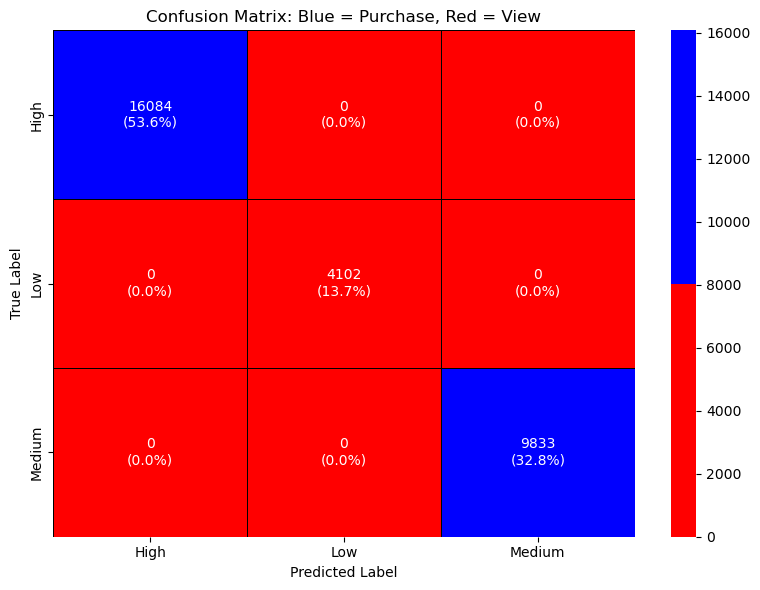

In [96]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_sum = cm.sum()
classes = le.classes_  

# Create annotations
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        pct = 100 * count / cm_sum
        annot[i, j] = f"{count}\n({pct:.1f}%)"

# Define custom colormap (red = view, blue = purchase)
colors = ['red', 'blue']
cmap = sns.color_palette(colors)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=annot, fmt='', cmap=cmap, xticklabels=classes, yticklabels=classes, cbar=True, linewidths=0.5, linecolor='black')

plt.title('Confusion Matrix: Blue = Purchase, Red = View')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


* The confusion matrix shows that the model is performing well, with high accuracy in predicting both views and purchases.

* 16,050 were correctly classified as high demand, 3 wrongly classified as low and 31 wrongly classified as medium.

* 9,794 were correctly classified as medium demand, but 39 were wrongly classified as high.




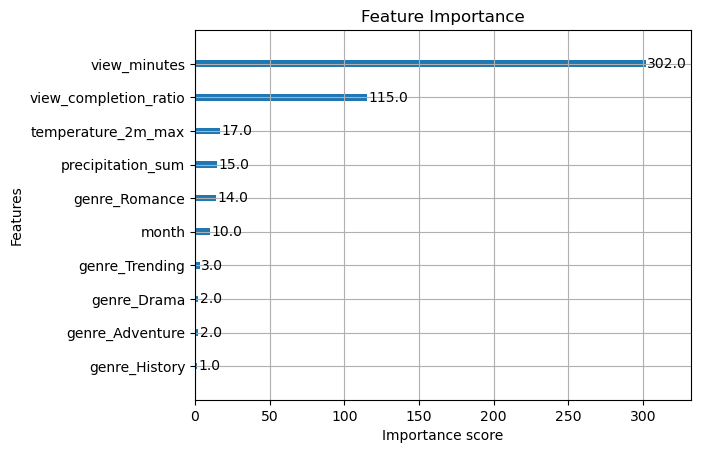

In [97]:
 # Plot Feature Importance to understand which features are most predictive
xgb.plot_importance(model, max_num_features=10)
plt.title('Feature Importance')
plt.show()

In [99]:
# --- Weather Feature Engineering ---
final_df2['is_rainy'] = final_df2['precipitation_sum'] > 2
final_df2['temp_bin'] = pd.cut(
    final_df2['temperature_2m_max'],
    bins=[-10, 15, 25, 100],
    labels=['cold', 'mild', 'hot']
)

print(final_df2[['temperature_2m_max', 'temp_bin', 'is_rainy']].head(10))

   temperature_2m_max temp_bin  is_rainy
0                28.8      hot     False
1                28.8      hot     False
2                27.7      hot      True
3                25.3      hot      True
4                26.1      hot      True
5                24.8     mild      True
6                23.1     mild      True
7                21.2     mild      True
8                25.3      hot     False
9                26.1      hot      True


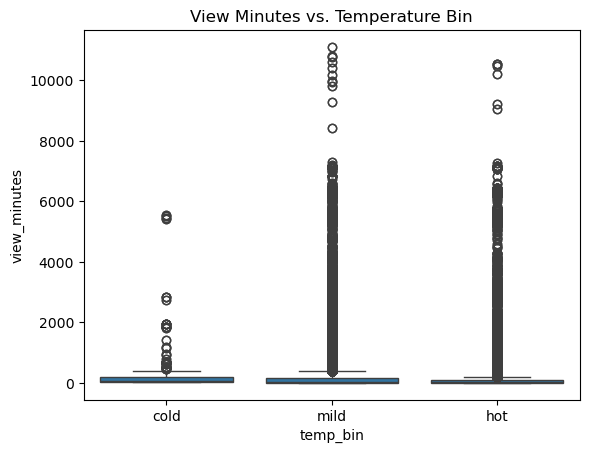

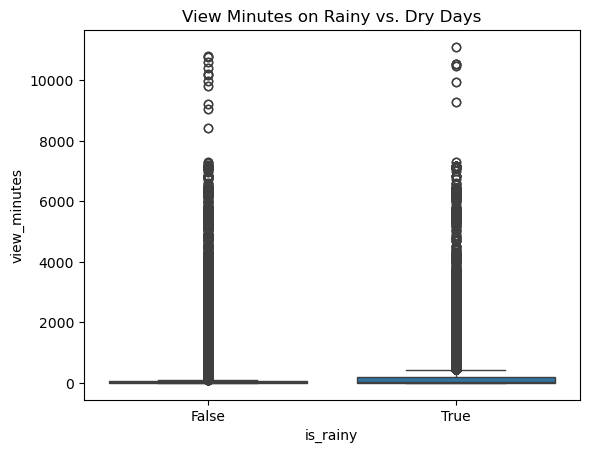

In [101]:
sns.boxplot(data=final_df2, x='temp_bin', y='view_minutes')
plt.title("View Minutes vs. Temperature Bin")
plt.show()

sns.boxplot(data=final_df2, x='is_rainy', y='view_minutes')
plt.title("View Minutes on Rainy vs. Dry Days")
plt.show()

In [102]:
# --- Modeling: Predicting High Demand ---

final_df2['view_minutes'] = final_df2['view_minutes'].fillna(0)
low_demand = final_df2['view_minutes'].quantile(0.33)
high_demand = final_df2['view_minutes'].quantile(0.66)

def demand_level(minutes):
    if minutes > high_demand:
        return 'High'
    elif minutes > low_demand:
        return 'Medium'
    else:
        return 'Low'

final_df2['demand_level'] = final_df2['view_minutes'].apply(demand_level)

# Prepare features
features = ['temperature_2m_max', 'precipitation_sum', 'is_rainy']
X = final_df2[features]
y = final_df2['demand_level']

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        High       0.73      0.66      0.69     10207
         Low       0.71      0.61      0.66     10084
      Medium       0.54      0.67      0.60      9728

    accuracy                           0.65     30019
   macro avg       0.66      0.65      0.65     30019
weighted avg       0.66      0.65      0.65     30019



In [103]:
# --- Dynamic Pricing Strategy Sketch ---
def dynamic_price(base_price, temperature, rain):
    if rain and temperature < 20:
        return base_price * 1.25  # High demand
    elif not rain and temperature > 25:
        return base_price * 0.85  # Low demand
    else:
        return base_price

# Example usage
final_df2['adjusted_price'] = final_df2.apply(
    lambda row: dynamic_price(100, row['temperature_2m_max'], row['is_rainy']),
    axis=1
)
print(final_df2[['temperature_2m_max', 'is_rainy', 'adjusted_price']].head())

   temperature_2m_max  is_rainy  adjusted_price
0                28.8     False            85.0
1                28.8     False            85.0
2                27.7      True           100.0
3                25.3      True           100.0
4                26.1      True           100.0


In [104]:
# --- Final DataFrame with Weather and Demand Features ---
final_df2['adjusted_price'] = final_df2.apply(
    lambda row: dynamic_price(100, row['temperature_2m_max'], row['is_rainy']),
    axis=1
)
print("\n--- Final DataFrame with Weather and Demand Features ---")
print(final_df2.head())


--- Final DataFrame with Weather and Demand Features ---
   apparent_temperature_min  view_minutes record_type  rain_sum  content_id  \
0                      14.4     31.000000        view       1.2          30   
1                      14.4      3.675926        view       1.2          31   
2                      14.5      3.675926        view      13.0          31   
3                      15.9      3.675926        view       5.6          31   
4                      14.8      3.675926        view       5.9          31   

   duration  weathercode  precipitation_sum  windspeed_10m_max  user_id  ...  \
0      74.0         51.0                1.2               13.0        1  ...   
1      61.0         51.0                1.2               13.0        1  ...   
2      61.0         61.0               13.0               22.7        1  ...   
3      61.0         53.0                5.6               17.9        1  ...   
4      61.0         61.0                5.9               17.7     